# EzTaoX fitting on DP1 DIA forced source catalog

This notebook demonstrates how to load DP1 data using LSDB and run EzTaoX fitting on DP1 light curves. 

**Note**: to run this notebook in RSP, please pip install the following packages 

In [2]:
%pip install lsdb hats nested_pandas --upgrade
%pip install arviz
%pip install eztaox
%pip install astropy --upgrade

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from upath import UPath

import numpy as np
import matplotlib.pyplot as plt
import arviz as az

import os
import lsdb
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import jax
import pyarrow as pa

from eztaox.kernels.quasisep import Exp
from eztaox.models import MultiVarModel
from eztaox.fitter import random_search
from nested_pandas import NestedDtype
from numpyro.infer import MCMC, NUTS, init_to_median
from numpyro.diagnostics import summary

### 1. Loading DP1 light curves

First, let’s load the DP1 light curves with LSDB. For this notebook, we will only load long light curves with `nDiaSources` > 500 and the necessary `diaObjectForcedSource` columns.

In [4]:
base_path = UPath("/rubin/lsdb_data")
dia_object_cat = lsdb.open_catalog(base_path / "dia_object_collection", \
                                   columns = ['ra', 'dec', 'diaObjectId', 'nDiaSources', 'diaObjectForcedSource'],\
                                  filters=[["nDiaSources", ">", 500]])
dia_object_cat

,ra,dec,diaObjectId,nDiaSources,diaObjectForcedSource
npartitions=208,,,,,
"Order: 6, Pixel: 130",double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou..."
"Order: 6, Pixel: 136",...,...,...,...,...
...,...,...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...


In [5]:
dia_object_cat.head()

ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
2528665081895373202  53.122135 -28.344551  609788873886662663          512   
2528689212471481767  53.041797 -28.283192  609789629800906756          581   
2528689652733440700  53.033514 -28.243268  611253766972244112          567   
2528691786073128755  52.898762 -28.193302  611253766972243969          548   
2528711291375799141  53.321787 -28.312488  609789492361953287          513   

                                                 diaObjectForcedSource  
_healpix_29                                                             
2528665081895373202  [{parentObjectId: 0, coord_ra: 53.122135, coor...  
2528689212471481767  [{parentObjectId: 0, coord_ra: 53.041797, coor...  
2528689652733440700  [{parentObjectId: 0, coord_ra: 53.033514, coor...  
2528691786073128755  [{parentObjectId: 0, coord_ra: 52.898762, coor...  
2528711291375799141  [{parentObjectId: 0, coord_ra: 53.321787, coor...

### 1.1 Clean light curves

We will remove all observations with a flag, and keep only objects with detections in both the r and i bands. 

We will also clean the light curves by:
- removing 10-sigma outliers within each night
- binning the data into nightly epochs by taking the mean magnitude for each night 
- updating the magnitude uncertainties by adding, in quadrature, the mean magnitude error and the within-night standard deviation of the magnitudes

In [6]:
flag_subcols = [c for c in dia_object_cat["diaObjectForcedSource"].columns if "Flag" in c]
expr = " and ".join([f"diaObjectForcedSource.{c} != 1" for c in flag_subcols])
dia_object_cat = dia_object_cat.query(expr)
dia_object_cat = dia_object_cat.map_partitions(lambda df: df.dropna(subset=["diaObjectForcedSource"]))

dia_object_cat = dia_object_cat.query("diaObjectForcedSource.band in ['r','i']")
dia_object_cat = dia_object_cat.map_partitions(lambda df: df.dropna(subset=["diaObjectForcedSource"]))

In [7]:
dia_object_cat.head()

ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
2528665081895373202  53.122135 -28.344551  609788873886662663          512   
2528689212471481767  53.041797 -28.283192  609789629800906756          581   
2528689652733440700  53.033514 -28.243268  611253766972244112          567   
2528691786073128755  52.898762 -28.193302  611253766972243969          548   
2528711291375799141  53.321787 -28.312488  609789492361953287          513   

                                                 diaObjectForcedSource  
_healpix_29                                                             
2528665081895373202  [{parentObjectId: 0, coord_ra: 53.122135, coor...  
2528689212471481767  [{parentObjectId: 0, coord_ra: 53.041797, coor...  
2528689652733440700  [{parentObjectId: 0, coord_ra: 53.033514, coor...  
2528691786073128755  [{parentObjectId: 0, coord_ra: 52.898762, coor...  
2528711291375799141  [{parentObjectId: 0, coord_ra: 53.321787, coor...

In [17]:
def prepare_lightcurves(time, band, mag, magerr, binning=True):
    times, mags, magerrs = {}, {}, {}

    for b in np.unique(band):
        mask = band == b
        time_band = time[mask]
        mag_band = mag[mask]
        magerr_band = magerr[mask]
        
        # Remove 10 sigma outliers in each band
        sigma = np.abs(mag_band - np.nanmean(mag_band)) / np.nanstd(mag_band)
        sigma_mask = sigma < 10
        time_band = time_band[sigma_mask]
        mag_band = mag_band[sigma_mask]
        magerr_band = magerr_band[sigma_mask]

        if binning: 
            # Get mean mag and magerr for each unique epoch
            times[b] = np.unique(np.round(time_band))
            mags[b] = []
            magerrs[b] = []
            for epoch in times[b]:
                epoch_mask = np.round(time_band) == epoch
                tmp_mag, tmp_err = combine_mag(mag_band[epoch_mask], magerr_band[epoch_mask])
                mags[b].append(tmp_mag)
                magerrs[b].append(tmp_err)
        else:
            times[b] = np.asarray(time_band)
            mags[b] =  np.asarray(mag_band)
            magerrs[b] =  np.asarray(magerr_band)
    
    # Format light curves for fitting
    X, y, yerr = format_lightcurves(times, mags, magerrs)
    return X, y, yerr

def combine_mag(mag, mag_err):
    ## add in quaduature mean(magerr) and std(mag) in each epoch
    ## e.g., https://arxiv.org/abs/2411.06617
    mag = np.asarray(mag)
    mag_err = np.asarray(mag_err)
    mag_w = np.nanmean(mag)
    mag_w_err = np.sqrt(np.nanmean(mag_err) ** 2 + np.nanstd(mag) ** 2)
    return mag_w, mag_w_err

def format_lightcurves(times, mags, magerrs):
    bands = times.keys()
    inds = jnp.argsort(jnp.concatenate([times[b] for b in bands]))
    X = (
        jnp.concatenate([times[b] for b in bands])[inds],
        jnp.concatenate(
            [i * jnp.ones_like(times[b], dtype=int) for i, b in enumerate(bands)]
        )[inds],
    )
    for b in bands:
        mags[b] = jnp.array(mags[b])
        mags[b] -= jnp.median(mags[b])
    y = jnp.concatenate([jnp.array(mags[b]) for b in bands])[inds]
    yerr = jnp.concatenate([jnp.array(magerrs[b]) for b in bands])[inds] 
    return X, y, yerr

### 2. EzTaoX fitting

First, we need to define a init sampler:

In [18]:
def init_sampler(fixed_params=None):
    if fixed_params is None:
        fixed_params = {}
        
    if "log_drw_scale" in fixed_params:
        log_drw_scale = fixed_params["log_drw_scale"]
    else:
        log_drw_scale = numpyro.sample(
            "log_drw_scale", dist.Uniform(jnp.log(10), jnp.log(100))
        )
    if "log_drw_sigma" in fixed_params:
        log_drw_sigma = fixed_params["log_drw_sigma"]
    else:
        log_drw_sigma = numpyro.sample(
            "log_drw_sigma", dist.Uniform(jnp.log(1e-2), jnp.log(10))
        )
    log_kernel_param = jnp.stack([log_drw_scale, log_drw_sigma])
    numpyro.deterministic("log_kernel_param", log_kernel_param)

    # parameters to relate the amplitudes in each band
    log_amp_scale = numpyro.sample("log_amp_scale", dist.Uniform(-2, 2))

    mean = numpyro.sample(
        "mean",
        dist.Uniform(low=jnp.asarray([-0.1, -0.1]), high=jnp.asarray([0.1, 0.1])),
    )

    # interband lags
    lag = numpyro.sample("lag", dist.Uniform(-10, 10))

    sample_params = {
        "log_kernel_param": log_kernel_param,
        "log_amp_scale": log_amp_scale,
        "mean": mean,
        "lag": lag,
    }
    return sample_params

And instantiate a multivariate model to use for fitting:

In [19]:
def multivar_model(X, y, yerr, has_lag=True, zero_mean=True):
    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=2.0)
    return MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)

In [20]:
def run_mle(model, init_sampler):
    fit_key = jax.random.PRNGKey(1)
    nSample = 1_000
    nBest = 5  # it seems like this number needs to be high
    bestP, ll = random_search(model, init_sampler, fit_key, nSample, nBest)
    return bestP, ll

def run_MCMC(
    objid, 
    X, 
    y, 
    yerr, 
    numpyro_model, 
    has_lag=True, 
    zero_mean=True, 
    fixed_params=None, 
    save_chains=False,
):
    nuts_kernel = NUTS(
        numpyro_model,
        dense_mass=True,
        target_accept_prob=0.9,
        init_strategy=init_to_median,
    )
    mcmc = MCMC(
        nuts_kernel,
        num_warmup=500,
        num_samples=1000,
        num_chains=1,
        # progress_bar=False,
    )
    mcmc_seed = 0
    mcmc.run(
        jax.random.PRNGKey(mcmc_seed),
        X,
        yerr,
        y=y,
        has_lag=has_lag,
        zero_mean=zero_mean,
        fixed_params=fixed_params,
    )
    if save_chains:
        idata = az.from_numpyro(mcmc)
        idata.to_netcdf(f"mcmc_chains/{objid}.nc")
    return summary(mcmc.get_samples(group_by_chain=True))

def numpyro_model(X, yerr, y=None, has_lag=True, zero_mean=True, fixed_params={}):
    sample_params = init_sampler(fixed_params={})
    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=1.0)  # init params for k are not used
    m = MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)
    m.sample(sample_params)

Let's finally put these steps all together:

In [21]:
def run_eztaox(objid, times, band, mag, magerr, *, save_chains=False):
    X, y, yerr = prepare_lightcurves(times, band, mag, magerr)
    #model = multivar_model(X, y, yerr, has_lag=True, zero_mean=True)
    #bestP, ll = run_mle(X, y, yerr, model, init_sampler)
    mcmc_summary = run_MCMC(
        objid,
        X,
        y,
        yerr,
        numpyro_model,
        has_lag=True,
        zero_mean=True,
        fixed_params={"log_drw_scale": jnp.log(100.0)},
        save_chains=save_chains,
    )
    return make_nested(mcmc_summary)

def make_nested(summary):
    nested_dict = {}
    for key in summary:
        for key2 in summary[key]:
            nested_dict[f"{key}.{key2}"] = [summary[key][key2]]
    return nested_dict

And run it all with LSDB, parallelizing the computation:

In [22]:
# Metadata for the MCMC result
nested_subcols = ["mean","std","median","5.0%","95.0%","n_eff","r_hat"]
nested_cols = ["lag", "log_amp_scale", "log_drw_scale", "log_drw_sigma", "log_kernel_param", "mean"]
meta = {col: NestedDtype({sc: pa.float64() for sc in nested_subcols}) for col in nested_cols}

In [23]:
result = dia_object_cat.map_rows(
    run_eztaox,
    # We only need the forced sources time band and mag info
    columns=["diaObjectId"] + [f"diaObjectForcedSource.{col}" for col in ["midpointMjdTai", "band", "psfMag", "psfMagErr"]],
    row_container="args",
    append_columns=True,
    save_chains=True, # By default, it is False
    meta=meta,
)
result

,ra,dec,diaObjectId,nDiaSources,diaObjectForcedSource,lag,log_amp_scale,log_drw_scale,log_drw_sigma,log_kernel_param,mean
npartitions=208,,,,,,,,,,,
"Order: 6, Pixel: 130",double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ...","nested<mean: [double], std: [double], median: ..."
"Order: 6, Pixel: 136",...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...,...,...,...,...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...,...,...,...,...,...,...


In [24]:
# Create a directory to store the mcmc chains
os.makedirs("mcmc_chains", exist_ok=True)

In [25]:
from dask.distributed import Client
with Client(n_workers=4):
    df = result.compute()
df

ERROR:tornado.application:Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='jenniferli.nb.data.lsst.cloud', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger valu

ERROR:tornado.application:Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='jenniferli.nb.data.lsst.cloud', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger valu

e for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --session-token-expiration if necessary
warmup:   1%|▏         | 19/1500 [00:06<05:36,  4.41it/s, 255 steps of size 3.20e-02. acc. prob=0.80]]

sample:  66%|██████▌   | 991/1500 [00:06<00:00, 736.43it/s, 31 steps of size 7.16e-02. acc. prob=0.93]

sample: 100%|██████████| 1500/1500 [00:07<00:00, 202.17it/s, 63 steps of size 7.16e-02. acc. prob=0.93] 


  0%|          | 0/1500 [00:00<?, ?it/s]

sample: 100%|██████████| 1500/1500 [00:05<00:00, 274.68it/s, 7 steps of size 3.48e-01. acc. prob=0.93]  


ra        dec         diaObjectId  nDiaSources  \
_healpix_29                                                                  
2528665081895373202  53.122135 -28.344551  609788873886662663          512   
2528689212471481767  53.041797 -28.283192  609789629800906756          581   
...                        ...        ...                 ...          ...   
2528746659668617474   52.95461 -27.948373  611255141361778689          552   
2528749594173367688  53.137026 -27.863437  611255072642301964          559   

                                                 diaObjectForcedSource  \
_healpix_29                                                              
2528665081895373202  [{parentObjectId: 0, coord_ra: 53.122135, coor...   
2528689212471481767  [{parentObjectId: 0, coord_ra: 53.041797, coor...   
...                                                                ...   
2528746659668617474  [{parentObjectId: 0, coord_ra: 52.95461, coord...   
2528749594173367688  [{parentObjectId: 0, coord_ra: 53.137026, coor...   

                                                                   lag  \
_healpix_29                                                              
2528665081895373202  [{mean: 0.151131, std: 5.758481, median: 0.391...   
2528689212471481767  [{mean: 0.754055, std: 5.161726, median: 1.153...   
...                                                                ...   
2528746659668617474  [{mean: 0.321296, std: 5.215405, median: 0.553...   
2528749594173367688  [{mean: 0.504052, std: 5.930174, median: 0.849...   

                                                         log_amp_scale  \
_healpix_29                                                              
2528665081895373202  [{mean: -1.261393, std: 0.534904, median: -1.3...   
2528689212471481767  [{mean: -0.940512, std: 0.620543, median: -0.9...   
...                                                                ...   
2528746659668617474  [{mean: -0.687827, std: 0.48473, median: -0.65...   
2528749594173367688  [{mean: -1.117278, std: 0.622956, median: -1.2...   

                                                         log_drw_scale  \
_healpix_29                                                              
2528665081895373202  [{mean: 3.936901, std: 0.544942, median: 4.081...   
2528689212471481767  [{mean: 3.788197, std: 0.625127, median: 3.940...   
...                                                                ...   
2528746659668617474  [{mean: 3.726115, std: 0.599184, median: 3.826...   
2528749594173367688  [{mean: 3.914756, std: 0.559064, median: 4.074...   

                                                         log_drw_sigma  \
_healpix_29                                                              
2528665081895373202  [{mean: -4.363073, std: 0.223471, median: -4.4...   
2528689212471481767  [{mean: -4.330408, std: 0.259568, median: -4.4...   
...                                                                ...   
2528746659668617474  [{mean: -4.29569, std: 0.270576, median: -4.36...   
2528749594173367688  [{mean: -4.370827, std: 0.223155, median: -4.4...   

                                                      log_kernel_param  \
_healpix_29                                                              
2528665081895373202  [{mean: array([ 3.93690107, -4.3630727 ]), std...   
2528689212471481767  [{mean: array([ 3.78819693, -4.33040846]), std...   
...                                                                ...   
2528746659668617474  [{mean: array([ 3.72611469, -4.29568959]), std...   
2528749594173367688  [{mean: array([ 3.91475587, -4.37082678]), std...   

                                                                  mean  
_healpix_29                                                             
2528665081895373202  [{mean: array([0.00235761, 0.0012249 ]), std: ...  
2528689212471481767  [{mean: array([-0.0001372 , -0.00270772]), std...  
...                                                                ...  
25

We can load one of the chains as follows:

In [26]:
az.from_netcdf("mcmc_chains/611254385447534607.nc")

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                 (chain: 1, draw: 1000, log_kernel_param_dim_0: 2,
│                                    mean_dim_0: 2)
│       Coordinates:
│         * chain                   (chain) int64 8B 0
│         * draw                    (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│         * log_kernel_param_dim_0  (log_kernel_param_dim_0) int64 16B 0 1
│         * mean_dim_0              (mean_dim_0) int64 16B 0 1
│       Data variables:
│           lag                     (chain, draw) float64 8kB ...
│           log_amp_scale           (chain, draw) float64 8kB ...
│           log_drw_scale           (chain, draw) float64 8kB ...
│           log_drw_sigma           (chain, draw) float64 8kB ...
│           log_kernel_param        (chain, draw, log_kernel_param_dim_0) float64 16kB ...
│           mean                    (chain, draw, mean_dim_0) float64 16kB ...
│       Attributes:
│           created_at:                 2026-04-13T19:10:45.387597+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.19.0
├── Group: /sample_stats
│       Dimensions:    (chain: 1, draw: 1000)
│       Coordinates:
│         * chain      (chain) int64 8B 0
│         * draw       (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│       Data variables:
│           diverging  (chain, draw) bool 1kB ...
│       Attributes:
│           created_at:                 2026-04-13T19:10:45.396427+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.0.0
│           creation_library_language:  Python
│           inference_library:          numpyro
│           inference_library_version:  0.19.0
└── Group: /observed_data
        Dimensions:   (gp_dim_0: 29)
        Coordinates:
          * gp_dim_0  (gp_dim_0) int64 232B 0 1 2 3 4 5 6 7 ... 21 22 23 24 25 26 27 28
        Data variables:
            gp        (gp_dim_0) float32 116B ...
        Attributes:
            created_at:                 2026-04-13T19:10:45.401408+00:00
            creation_library:           ArviZ
            creation_library_version:   1.0.0
            creation_library_language:  Python
            inference_library:          numpyro
            inference_library_version:  0.19.0

### 3. Plot some results

In [34]:
def plot_MCMC(
    X, y, yerr, mcmc, outfile=None, trace_vars=None, has_lag=True, zero_mean=True
):
    # Draw one sample from MCMC and extract parameters
    mcmc_samples = {
        k: v.stack(sample=("chain", "draw")).transpose("sample", ...)
             .values
        for k, v in mcmc.posterior.data_vars.items()
    }
    sample_idx = 100  # Use first sample
    params_sample = {k: v[sample_idx] for k, v in mcmc_samples.items()}

    band_colors = {
        "u": "blue",
        "g": "green",
        "r": "red",
        "i": "orange",
        "z": "purple",
        "y": "brown",
    }

    # Create prediction grid (finer time resolution for smooth curves)
    pred_times = jnp.linspace(X[0].min(), X[0].max(), 200)
    pred_X = (pred_times, jnp.zeros_like(pred_times, dtype=int))  # Band 0

    # Make prediction for each band
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[1.75, 1], wspace=0.15)

    ax0 = fig.add_subplot(ax[0, 0])
    n_vars = len(trace_vars)
    ax_r = ax[0, 1].subgridspec(nrows=n_vars, ncols=2, hspace=0.4, wspace=0.4)
    ax1 = np.asarray(
        [[fig.add_subplot(ax_r[r, c]) for c in range(2)] for r in range(n_vars)],
        dtype=object,
    )

    nBand = len(np.unique(X[1]))
    k = Exp(scale=100.0, sigma=1.0)  # init params for k are not used
    m = MultiVarModel(X, y, yerr, k, nBand, has_lag=has_lag, zero_mean=zero_mean)
    m.sample(params_sample)
    model = m

    for i, b in enumerate("ri"):
        # Create prediction for this band
        pred_X_band = (pred_times, jnp.full_like(pred_times, i, dtype=int))
        mu, std = model.pred(params_sample, pred_X_band)

        # Plot observed data
        mask = X[1] == i

        # Plot prediction
        ax0.plot(pred_times, mu, "-", linewidth=1, alpha=0.5, color=band_colors[b])
        ax0.fill_between(
            pred_times, mu - std, mu + std, alpha=0.2, color=band_colors[b]
        )
        ax0.errorbar(
            X[0][mask],
            y[mask],
            yerr=yerr[mask],
            fmt=".",
            label=b,
            zorder=-100,
            color=band_colors[b],
        )

        ax0.set_xlabel("Time (days)",fontsize=12)
        ax0.set_ylabel("Scaled Magnitude",fontsize=12)
        ax0.tick_params(direction="in")
        ax0.invert_yaxis()
        ax0.legend(loc="upper left")

    for iv, var in enumerate(trace_vars):
        ax1[iv, 0].plot(np.array(mcmc.posterior[var]).flatten())
        ax1[iv, 1].hist(np.array(mcmc.posterior[var]).flatten())
        #ax1[iv, 0].set_ylabel(var)
        ax1[iv, 1].set_ylabel(var)
        ax1[iv, 1].yaxis.set_label_position("right")
        ax1[iv, 0].tick_params(direction="in")
        ax1[iv, 1].tick_params(direction="in")
    
    ax1[0, 0].set_title("Trace")
    ax1[0, 1].set_title("Posterior")
    
    plt.tight_layout()
    if outfile != None:
        plt.savefig(outfile, bbox_inches="tight")
    else:
        plt.show()

/tmp/ipykernel_459/2431419765.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


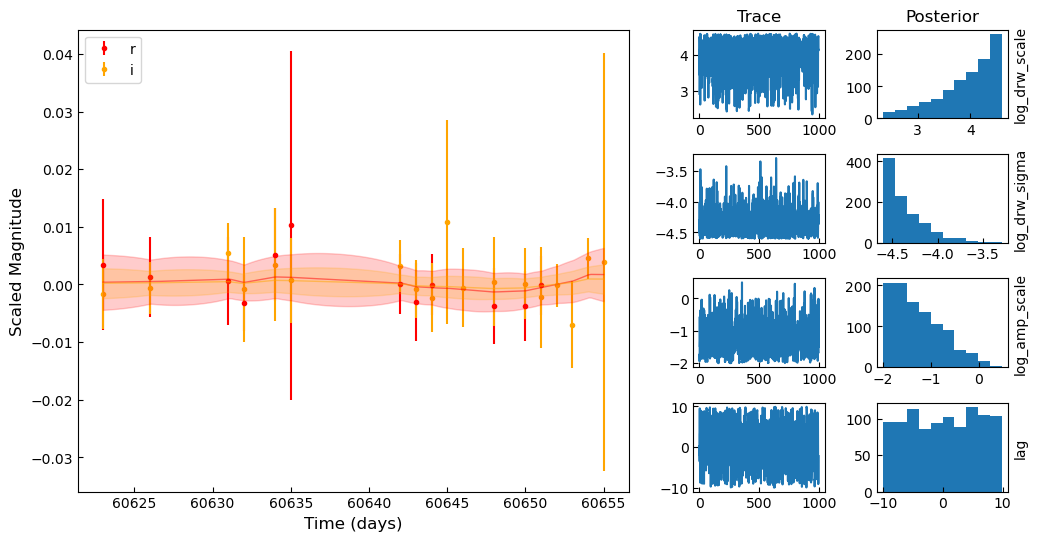

/tmp/ipykernel_459/2431419765.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


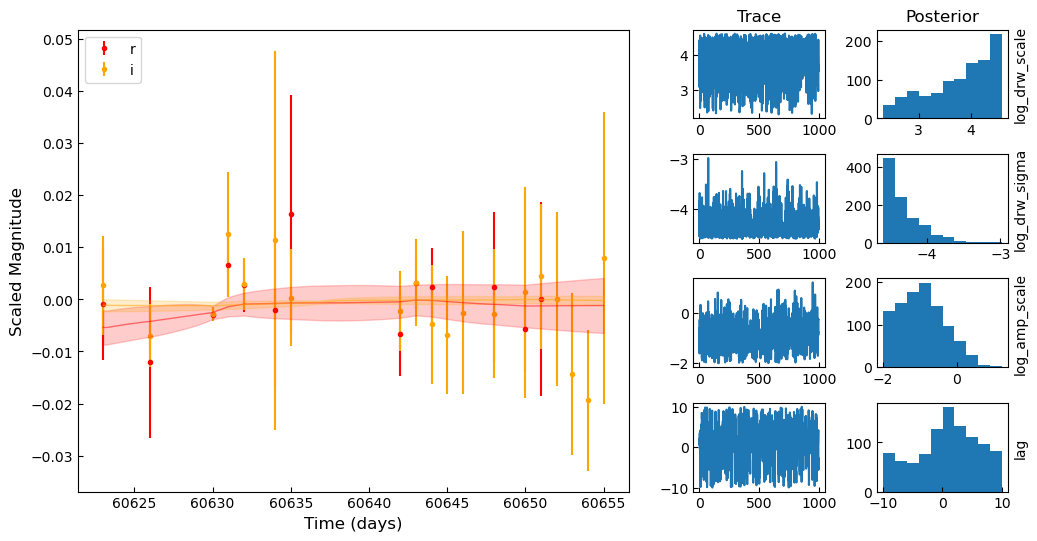

/tmp/ipykernel_459/2431419765.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


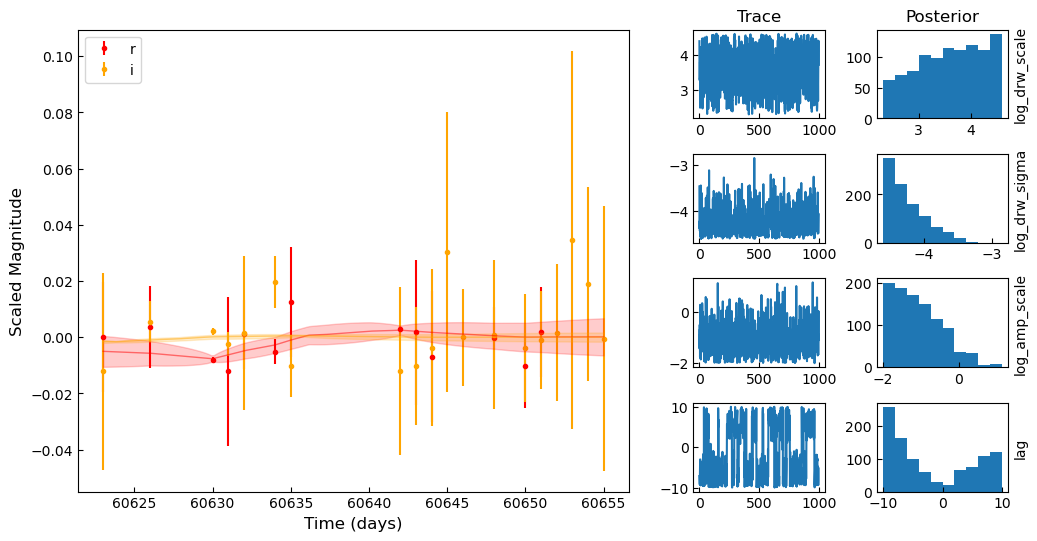

/tmp/ipykernel_459/2431419765.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


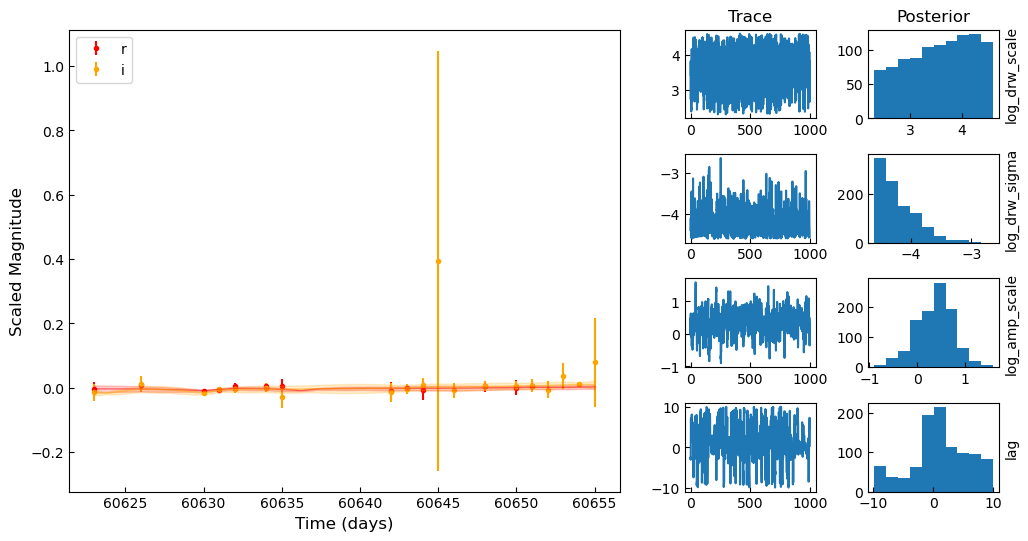

/tmp/ipykernel_459/2431419765.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


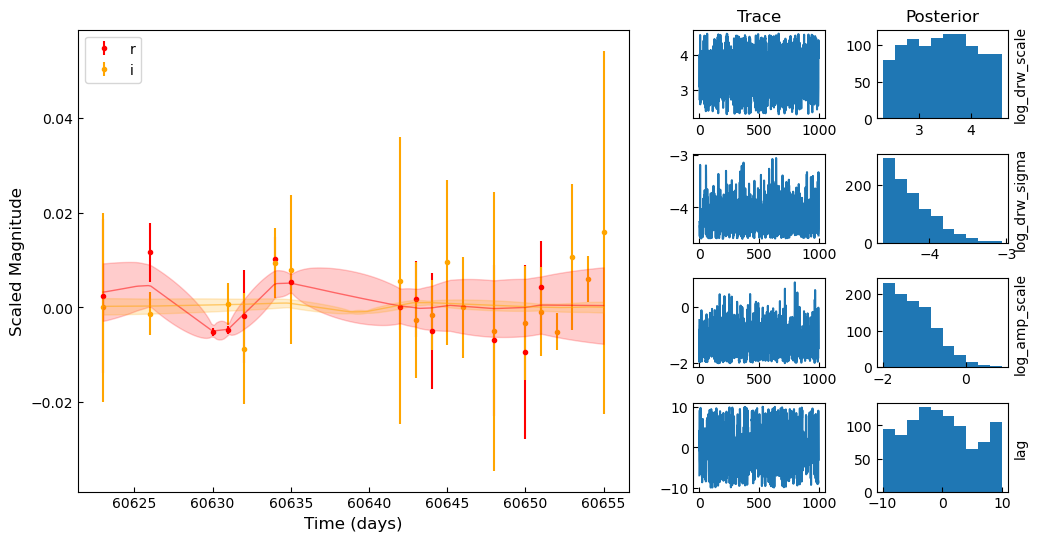

In [35]:
for i in range(5):

    ## run MLE, use results for MCMC fitting
    X, y, yerr = prepare_lightcurves(df.iloc[i].diaObjectForcedSource['midpointMjdTai'],\
                                     df.iloc[i].diaObjectForcedSource['band'],\
                                     df.iloc[i].diaObjectForcedSource['psfMag'],\
                                     df.iloc[i].diaObjectForcedSource['psfMagErr'])

    mcmc = az.from_netcdf("mcmc_chains/"+str(df.iloc[i].diaObjectId)+".nc")

    ## plot results
    trace_vars = ["log_drw_scale", "log_drw_sigma", "log_amp_scale", "lag"]
    plot_MCMC(
        X,
        y,
        yerr,
        mcmc,
        trace_vars=trace_vars,
    )